# 12 — Train Face Model

Fine-tunes every model in `config.FACE_MODELS_TO_RUN` on the face crops
produced by `03_preprocess_face.ipynb`.

**Depends on:** `03_preprocess_face.ipynb` having been run (metadata + PNG crops must exist).

**Score-weighted loss** is on by default — frames that scored high during
preprocessing contribute more to the gradient.  Toggle with `use_score_weights`.

**NPZ cache** is built once per split and reused on subsequent runs.
Set `use_cache=False` to skip it (e.g. when disk space is tight).

**Outputs** (per model, written to `../experiments/face_unimodal/<version>/<slug>/`):
- `model/best_model.pt` — best checkpoint (by dev macro-F1)
- `model/arch.txt`      — architecture name for reloading
- `history.csv`
- `config.json`
- `train_metrics.json`
- `power_samples.csv`

In [3]:
import os
import sys

_here = os.path.abspath(os.getcwd())
_root = _here if os.path.isdir(os.path.join(_here, 'src')) else os.path.abspath(os.path.join(_here, '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

In [4]:
from src.config import (
    DEVICE,
    FACE_MODELS_TO_RUN,
    FACE_TRAIN_BATCH_SIZE, FACE_TRAIN_EPOCHS, FACE_TRAIN_LR,
    FACE_WEIGHT_DECAY, FACE_WARMUP_RATIO, FACE_GRAD_CLIP_NORM,
    FACE_USE_SCORE_WEIGHTS, FACE_SCORE_WEIGHT_POWER,
    FACE_SCORE_WEIGHT_MIN, FACE_SCORE_WEIGHT_NORMALIZE,
    FACE_USE_CACHE, FACE_CACHE_DIR,
    VERSION,
)
from src.data.face_dataset import load_face_metadata, LABEL2ID, ID2LABEL
from src.training.train_face import train_one_face

print('Device:', DEVICE)
print('Models to train:', FACE_MODELS_TO_RUN)

Device: cuda
Models to train: ['vit_b_16', 'mobilenet_v3_small']


## Load metadata

In [5]:
train_df = load_face_metadata('train', version=VERSION)
dev_df   = load_face_metadata('dev',   version=VERSION)
test_df  = load_face_metadata('test',  version=VERSION)

print(f'Train frames : {len(train_df)}')
print(f'Dev frames   : {len(dev_df)}')
print(f'Test frames  : {len(test_df)}')
print(f'Classes      : {list(LABEL2ID.keys())}')

Train frames : 47800
Dev frames   : 5324
Test frames  : 12117
Classes      : ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']


e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\src\data\face_dataset.py:112: DtypeWarning: Columns (0: total_frames, 1: frame_idx, 2: pred_prob) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(meta_path)


## Optional — override training hyperparameters

Change values here to experiment without touching `src/config.py`.
Leave as-is to use the config defaults.

In [6]:
# ── Hyperparameter overrides ───────────────────────────────────────────────────
batch_size        = FACE_TRAIN_BATCH_SIZE   # e.g. 64 if you have GPU RAM to spare
epochs            = FACE_TRAIN_EPOCHS       # e.g. 10 for a quick test
lr                = FACE_TRAIN_LR
weight_decay      = FACE_WEIGHT_DECAY
warmup_ratio      = FACE_WARMUP_RATIO
grad_clip         = FACE_GRAD_CLIP_NORM

# ── Score weighting ───────────────────────────────────────────────────────────
use_score_weights = FACE_USE_SCORE_WEIGHTS   # set False → plain CE loss
score_power       = FACE_SCORE_WEIGHT_POWER  # w = score^power
score_min         = FACE_SCORE_WEIGHT_MIN    # floor weight
score_normalize   = FACE_SCORE_WEIGHT_NORMALIZE

# ── NPZ cache ─────────────────────────────────────────────────────────────────
use_cache  = FACE_USE_CACHE   # set False to always load PNGs from disk
cache_dir  = FACE_CACHE_DIR

print('Running with:')
print(f'  batch={batch_size}, epochs={epochs}, lr={lr}, wd={weight_decay}')
print(f'  score_weights={use_score_weights}, power={score_power}, min={score_min}')
print(f'  cache={use_cache}')

Running with:
  batch=32, epochs=20, lr=0.0001, wd=0.01
  score_weights=True, power=1.0, min=0.1
  cache=True


## Train

In [7]:
run_dirs = []

for model_name in FACE_MODELS_TO_RUN:
    run_dir = train_one_face(
        model_name=model_name,
        train_df=train_df,
        dev_df=dev_df,
        test_df=test_df,
        batch_size=batch_size,
        epochs=epochs,
        lr=lr,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        grad_clip=grad_clip,
        use_score_weights=use_score_weights,
        score_power=score_power,
        score_min=score_min,
        score_normalize=score_normalize,
        use_cache=use_cache,
        cache_dir=cache_dir,
        version=VERSION,
        device=DEVICE,
    )
    run_dirs.append(run_dir)

print('\nAll run directories:')
for d in run_dirs:
    print(' ', d)


  Face model      : vit_b_16
  Run dir         : ../experiments/face_unimodal\v1\vit_b_16
  Device          : cuda
  Freeze epochs   : 3
  Backbone LR     : 1.00e-05  |  Head LR: 1.00e-04
  Label smoothing : 0.1
  Balanced sampler: True
  Params          : 85,804,039 trainable / 85,804,039 total
  Backbone frozen : 5,383 params active for first 3 epoch(s).
  [Epoch 01/20] [frozen] train_loss=2.0063  dev_loss=2.0143  dev_macro_f1=0.0932
    ↳ New best dev macro-F1: 0.0932 — checkpoint saved.
  [Epoch 02/20] [frozen] train_loss=1.8948  dev_loss=2.0183  dev_macro_f1=0.1102
    ↳ New best dev macro-F1: 0.1102 — checkpoint saved.
  [Epoch 03/20] [frozen] train_loss=1.8395  dev_loss=1.9876  dev_macro_f1=0.1274
    ↳ New best dev macro-F1: 0.1274 — checkpoint saved.

  [Epoch 4] Backbone unfrozen — 85,804,039 params now active.
  [Epoch 04/20] train_loss=1.6045  dev_loss=1.8697  dev_macro_f1=0.2201
    ↳ New best dev macro-F1: 0.2201 — checkpoint saved.
  [Epoch 05/20] train_loss=1.3878  dev

## Training history

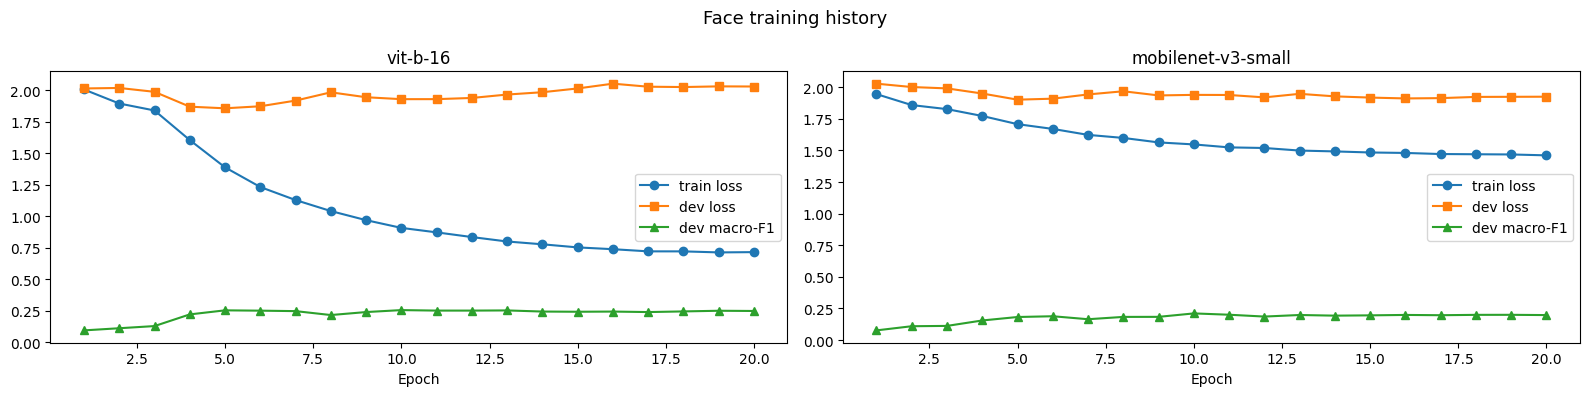

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(run_dirs), figsize=(8 * len(run_dirs), 4), squeeze=False)

for ax, run_dir in zip(axes[0], run_dirs):
    history_path = os.path.join(run_dir, 'history.csv')
    if not os.path.exists(history_path):
        continue
    hist = pd.read_csv(history_path)
    ax.plot(hist['epoch'], hist['train_loss'],   label='train loss',   marker='o')
    ax.plot(hist['epoch'], hist['dev_loss'],     label='dev loss',     marker='s')
    ax.plot(hist['epoch'], hist['dev_macro_f1'], label='dev macro-F1', marker='^')
    ax.set_xlabel('Epoch')
    ax.set_title(os.path.basename(run_dir).replace('_', '-'))
    ax.legend()

plt.suptitle('Face training history', fontsize=13)
plt.tight_layout()
plt.show()